In [1]:
from IPython.display import Image, display
import pandas as pd

# Multi-Asset ETF Rotation
Author: Thomas O’Neill, Conway Zhou

## Background

Imagine a “basket” of different assets that you can buy and sell as a single investment at any time, while the fund manager handles buying and selling the assets themselves. That is what an Exchange-Traded Fund (ETF) essentially is: an investment fund that holds a collection of assets (stocks, bonds, etc.) and is traded on the stock exchange. There are several advantages to using an ETF, such as having to purchase just once in order to have access to a broad range of assets, and investments are spread across multiple assets, so if one underperforms, it does not hurt the overall portfolio.

A rotation strategy moves around investments to different ETFs that have stronger momentum to maximize the investments. **Mebane T. Faber** developed a rotation strategy which produced equity-like returns with reduced risk and smaller losses, as well as over 30 consecutive years of positive returns, from 1972-2005. His strategy was effectively as followed:
- Each asset holds exactly 20% of the portfolio.
- At the end of every month, look at each of the 5 assets independently. For each asset, check whether the current price is above or below its 10-month moving average.
- If an asset is above, hold it
- If an asset is below, move its 20% to cash so it can earn the T-bill rate as a safe return

However, in an era with machine learning, Faber's strategy can certainly be improved, such as taking into account more macroeconomic factors and addressing position sizing. As such, our project proposes **a machine learning-driven multi-asset ETF rotation strategy in hopes that it can be more effective than Faber's.**

Our result compares Faber's strategy (which we call the "Faber baseline") with our ML strategy through a time period between October 2010 to August 2024.

## Light Gradient-Boosting Machine (LightGBM)
Gradient Boosting is a technique that builds many simple decision trees one after another, with each new tree learning from the mistakes of the previous one to gradually improve the predictions. The final model is the combined result of all those trees working together. We are especially using a light version because it is designed to be faster and more memory efficient than older gradient boosting methods.

We chose to use LightGBM for our ML strategy due to the following reasons:
- It has built in support for ranking problems
- It does not require much data preprocessing
- It is fast to train and tune


## ML Strategy
LightGBM initially trains on prior 36 months of data to identify which feature patterns (specifically, macroeconomical and technical indicators) tend to correspond to higher-ranked ETFs. At the end of each month, LightGBM scores the 5 assets. This score is linearly normalized, multiplied by the risk parity, then normalized again. This final score is how we allocate our investments.

To stay as updated as possible LightGBM model is “retrained” every 12 months.

### ETFs
We chose to use the following 5 ETFs as equivalents to Faber's assets
  Asset Class  | ETF | Faber Equivalent |
-------------|-----|-------------|
US Stocks   | SPY (SPDR S&P 500 ETF Trust) | US Equities (S&P 500) |
Intl Stocks | EFA (iShares MSCI EAFE ETF) | International Equities (MSCI EAFE) |
Bonds       | IEF (iShares 7-10 Year Treasury Bond ETF) | US Bonds (7-10 Year Treasury) |
Real Estate | VNQ (Vanguard Real Estate ETF) | Real Estate (US REITs) |
Commodities | DBC (Invesco DB Commodity Index Tracking Fund) | Commodities (GSCI) |

## Macroeconomic and Technical Indicators
Both macroeconomic and technical indicators were fed into LightGBM. The following indicators were specifically used

### Macroeconomic Indicators
Macroeconomic data was taken from Archival FRED (ALFRED), which records an indicator's vintage data, or information that was present at a certain date in history. This removed any lookahead bias from the revised data of the regular FRED database. That being said, the 10-year minus 2-year Treasury spread still used FRED, as it did not have vintage data in ALFRED. However, this data is rarely, if ever, revised in the first place. 
- **Federal Funds Rate (FEDFUNDS)**:The interest rate the Federal Reserve sets for overnight lending between banks. When it rises, borrowing gets more expensive, which tends to hurt equities and real estate but benefits bonds. When it falls, the opposite happens.
- **Consumer Price Index (CPIAUCSL)**: Measures the average change in prices consumers pay for goods and services; essentially the inflation rate. High inflation benefits commodities and real estate, while hurting bonds since inflation erodes fixed interest payments.
- **10Y-2Y Treasury Spread (T10Y2Y)**: The difference between long-term and short-term government bond yields. When it inverts (goes negative), it historically signals an upcoming recession, suggesting a rotation away from equities and commodities toward safer assets.
- **Industrial Production Index (INDPRO)**: Measures the output of the manufacturing, mining, and utilities sectors. A proxy for overall economic health — strong readings favour equities and commodities since a growing economy consumes more goods and raw materials.

### Technical Indicators
- **RSI (Relative Strength Index)**: Measures how fast and how much a price has moved recently, scaled 0–100. Above 70 suggests the asset may be overbought; below 30 suggests oversold. Gives the model a sense of short-term momentum.
- **MACD (Moving Average Convergence Divergence)**: Takes a fast and slow moving average of price and looks at the difference. When the fast average crosses above the slow one, it signals upward momentum; crossing below signals downward momentum.
- **Bollinger Bands**: A band drawn at ±2 standard deviations around a moving average. When price is near the upper band, the asset is trading high relative to recent history; near the lower band means trading low. A wider band indicates higher recent volatility.
- **SMA (20-Month)**: Simple moving average over 20 months. Smooths out price to show the longer-term trend. Distance from SMA indicates how far the current price has deviated from that trend.
- **SMA (10-Month) / Distance / Flag**: Faber's signal period. The distance from the 10-month SMA shows how far price is from the Faber threshold, and the binary flag (1 = above, 0 = below) is literally the same signal Faber uses, allowing LightGBM to learn from it directly.

In [2]:
features = pd.read_csv('../feature_engineer_csv.csv', parse_dates=['date'])

# Macro table
macro_rename = {
    'FEDFUNDS': 'Fed Funds Rate',
    'CPIAUCSL': 'CPI',
    'T10Y2Y':   '10Y-2Y Spread',
    'INDPRO':   'Industrial Production',
}
macro_df = features[['date'] + list(macro_rename.keys())].rename(columns=macro_rename).set_index('date')

# Technical table — core indicators per ETF (excludes close, high, low, open, volume, bollinger_bands)
ETFS = ['SPY', 'EFA', 'IEF', 'VNQ', 'DBC']
indicators = {
    'rsi':               'RSI',
    'macd':              'MACD',
    'sma':               'SMA',
    'dist_from_sma':     'Dist from SMA',
    'dist_from_10m_sma': 'Dist from 10M SMA',
    'above_10m_sma':     'Above 10M SMA',
}
tech_rename = {f'{etf}_{ind}': f'{etf} {name}' for etf in ETFS for ind, name in indicators.items()}
tech_cols   = [c for c in tech_rename if c in features.columns]
tech_df     = features[['date'] + tech_cols].rename(columns=tech_rename).set_index('date')

print('Macro Indicators')
display(macro_df)
print('\nTechnical Indicators')
display(tech_df)

Macro Indicators


,Fed Funds Rate,CPI,10Y-2Y Spread,Industrial Production
date,,,,
2007-09-30,4.94,208.292,0.62,114.3570
2007-10-31,4.76,208.903,0.54,113.9957
2007-11-30,4.49,210.565,0.93,113.9019
2007-12-31,4.24,211.160,0.99,113.9673
2008-01-31,3.94,212.516,1.50,114.2334
...,...,...,...,...
2024-07-31,5.33,313.534,-0.20,102.8887
2024-08-31,5.33,314.121,0.00,103.1389
2024-09-30,5.13,314.686,0.15,102.6418



Technical Indicators


,SPY RSI,SPY MACD,SPY SMA,SPY Dist from SMA,SPY Dist from 10M SMA,SPY Above 10M SMA,EFA RSI,EFA MACD,EFA SMA,EFA Dist from SMA,...,VNQ SMA,VNQ Dist from SMA,VNQ Dist from 10M SMA,VNQ Above 10M SMA,DBC RSI,DBC MACD,DBC SMA,DBC Dist from SMA,DBC Dist from 10M SMA,DBC Above 10M SMA
date,,,,,,,,,,,,,,,,,,,,,
2007-09-30,75.091566,NaN,97.266307,0.114295,0.048917,1,82.834203,NaN,40.742859,0.150969,...,32.316261,0.020823,-0.037595,0,72.026638,NaN,20.241359,0.127916,0.098347,1
2007-10-31,76.353727,NaN,98.345072,0.117023,0.052398,1,85.172458,NaN,41.451772,0.179363,...,32.601697,0.033126,-0.014908,0,77.712964,NaN,20.556759,0.205038,0.164789,1
2007-11-30,65.940739,NaN,99.138247,0.065167,0.007000,1,75.347496,NaN,42.002606,0.121721,...,32.661686,-0.066439,-0.089327,0,76.383661,NaN,20.838679,0.181330,0.130253,1
2007-12-31,63.340873,NaN,99.815289,0.046029,-0.009623,0,68.591218,NaN,42.396742,0.078162,...,32.688962,-0.117710,-0.118281,0,80.270654,NaN,21.136525,0.242767,0.174784,1
2008-01-31,51.689568,NaN,100.313548,-0.022096,-0.067854,0,55.022761,NaN,42.683817,-0.013125,...,32.743143,-0.126048,-0.105502,0,81.769846,NaN,21.476622,0.258741,0.175284,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,70.905991,38.022116,445.743410,0.210244,0.109372,1,63.091937,3.561400,68.267552,0.121223,...,75.404250,0.121041,0.099174,1,51.482578,0.434256,20.950806,-0.010173,-0.009224,0
2024-08-31,72.445038,40.537817,455.015787,0.213283,0.102044,1,65.665513,3.893119,69.239680,0.141523,...,76.234687,0.166718,0.122991,1,48.648786,0.346372,20.887187,-0.027824,-0.024488,0
2024-09-30,73.817234,42.971867,463.715179,0.215528,0.098596,1,66.293473,4.158037,69.974474,0.138384,...,76.834299,0.195463,0.134042,1,49.664544,0.285292,20.821286,-0.017690,-0.015168,0


## EDA Analysis


### ETF Adjusted Closing Prices
All 5 assets were affected by economic events in the United States. Notably, 4 of the 5 assets (except IEF) had at least a brief dip during the COVID-19 pandemic, while 3 assets (IEF, VNQ, DBC) were hit by the 2021-2022 inflation surge. This graph shows why a rotation strategy is important.

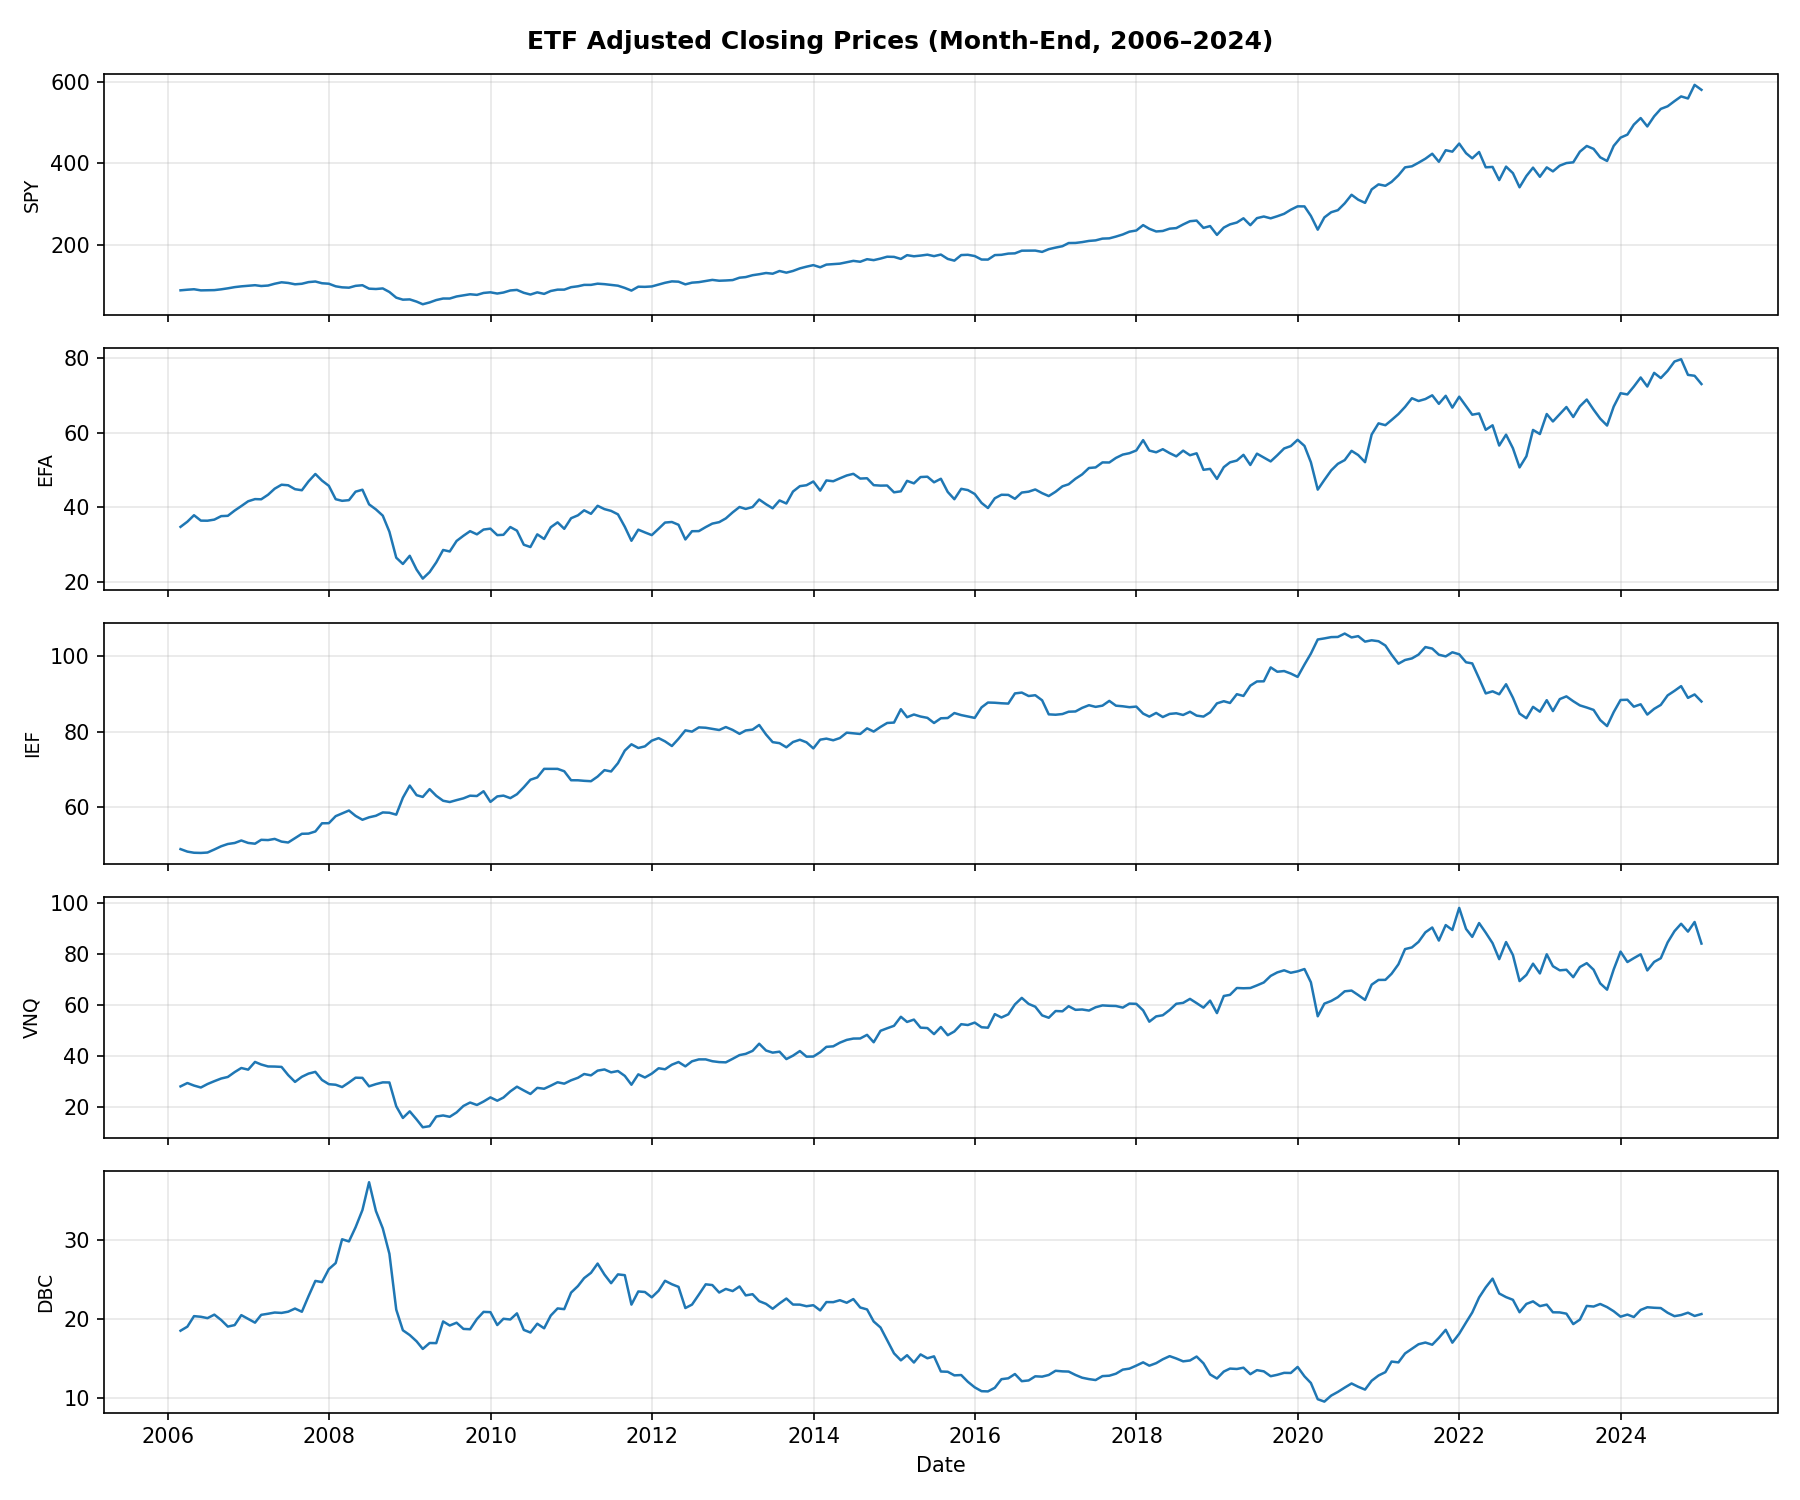

In [3]:
display(Image('../figures/price_charts.png'))

### Monthly Return Distributions
For each ETF, there is a different spread of monthly returns, showing that there are some ETFs that are more volatile than others. This graph shows the need for risk parity weighting, which we used alongside our LightGBM score to determine how we allocate our investments.

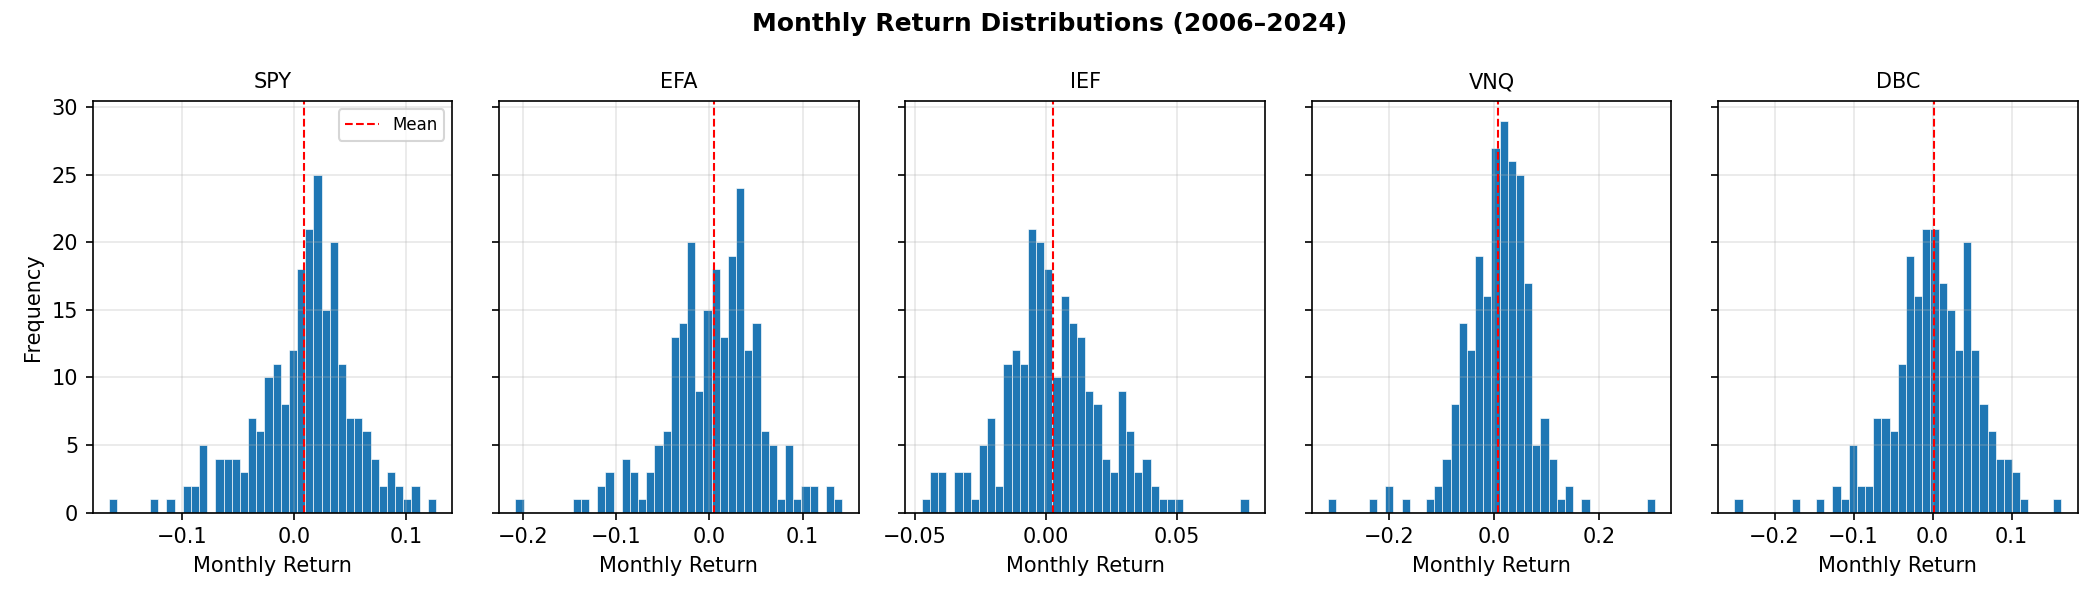

In [4]:
display(Image('../figures/return_distributions.png'))

### Average Rolling 12-Month Correlation
The ETFs feature mixed correlations with each other, with some having strong positive correlation (EFA and SPY), some having very little correlation (IEF and VNQ), and some even having correlation trending negatively (IEF and DBC). This is, again, why we need a rotation strategy, as one ETF doing well does not mean all ETFs are doing the same.

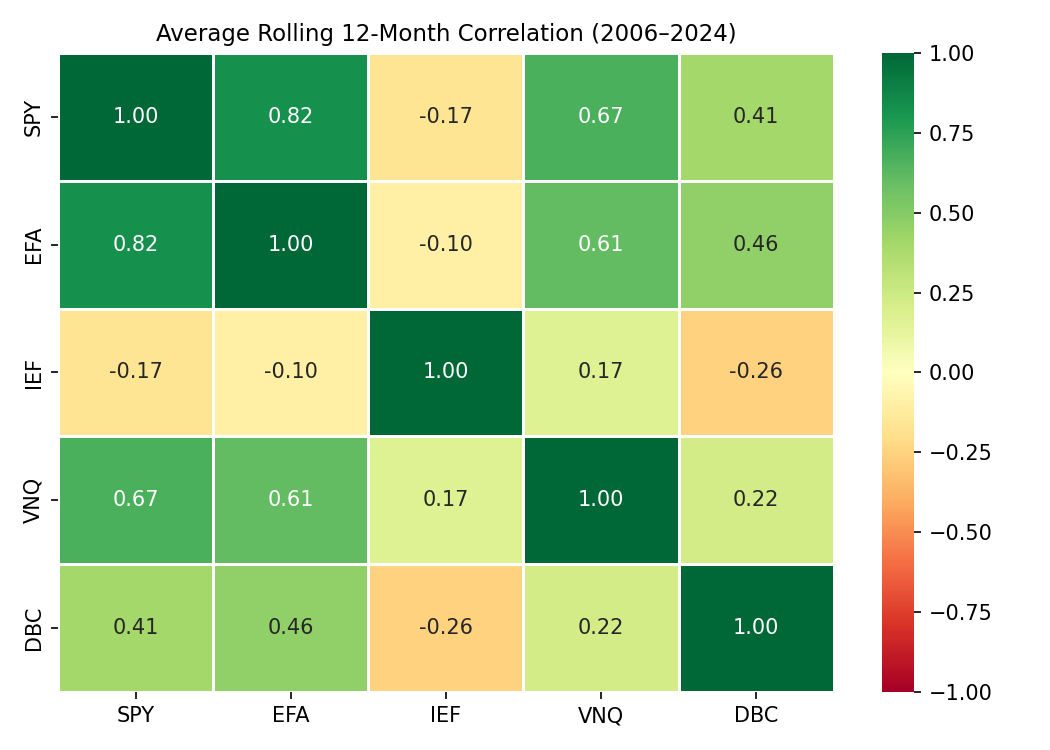

In [5]:
display(Image('../figures/rolling_correlation_heatmap.png'))

## Results

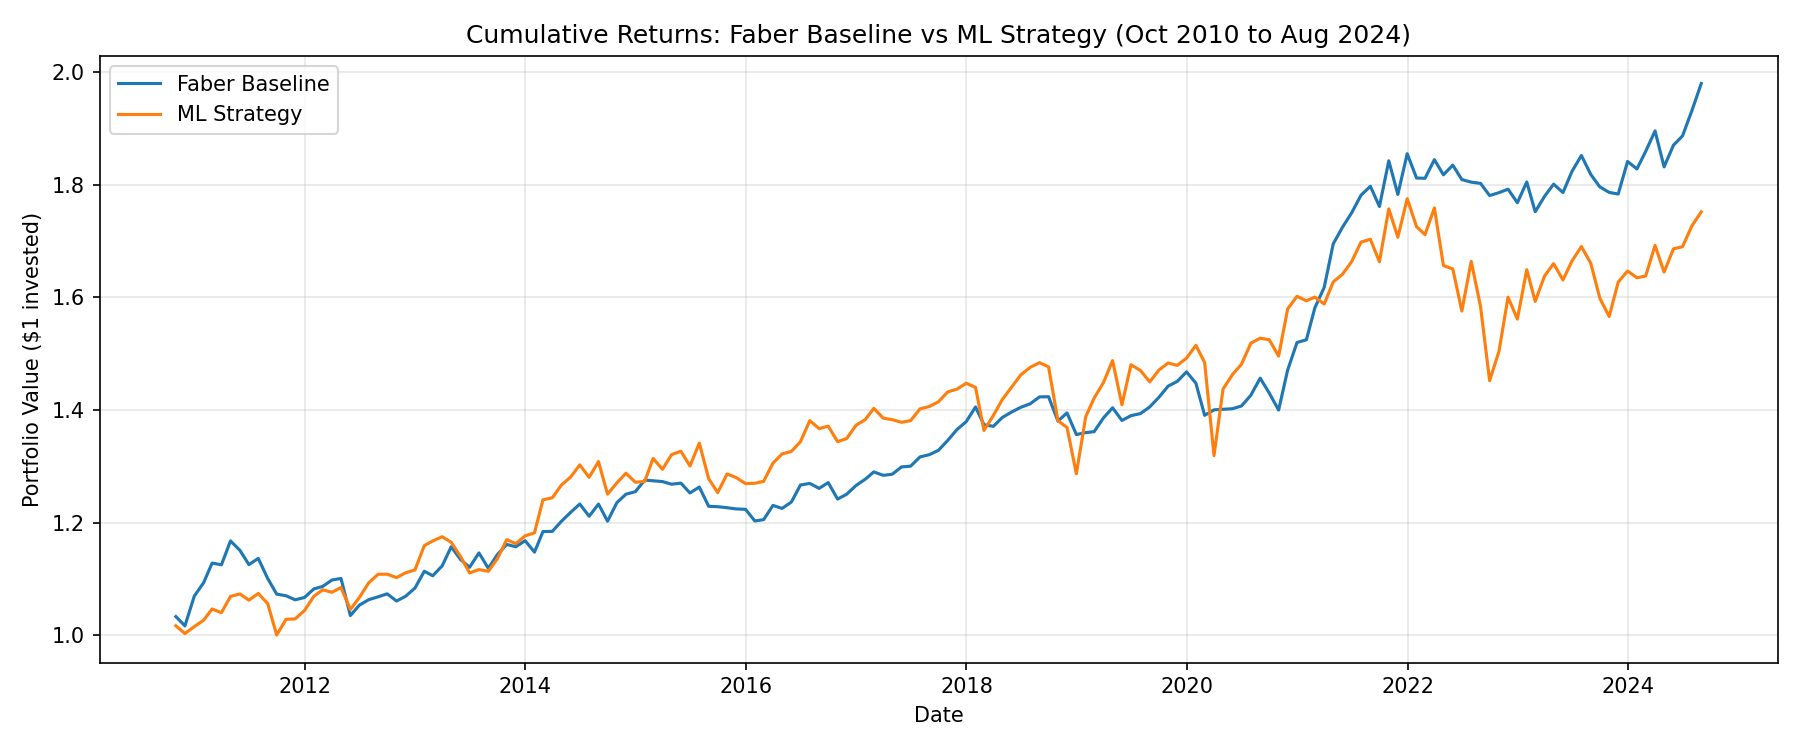

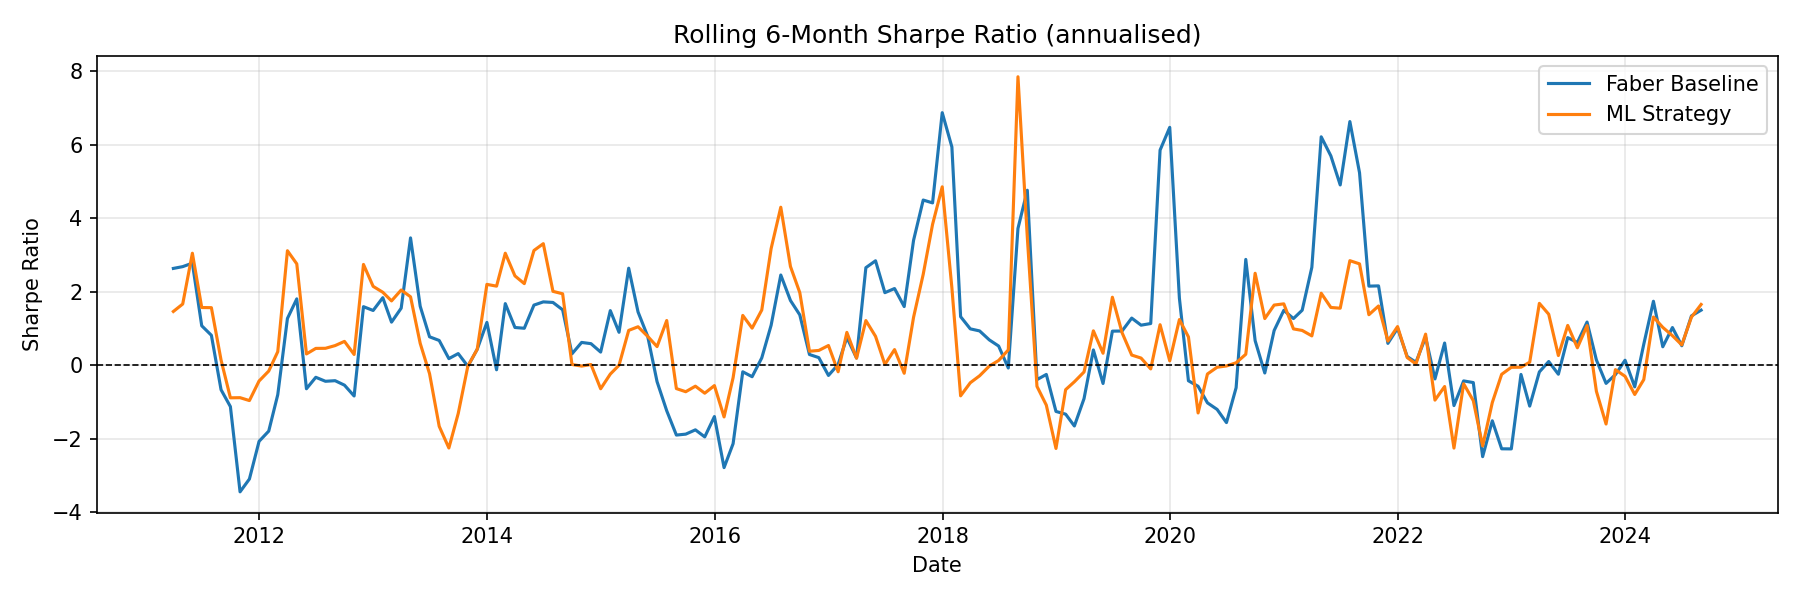

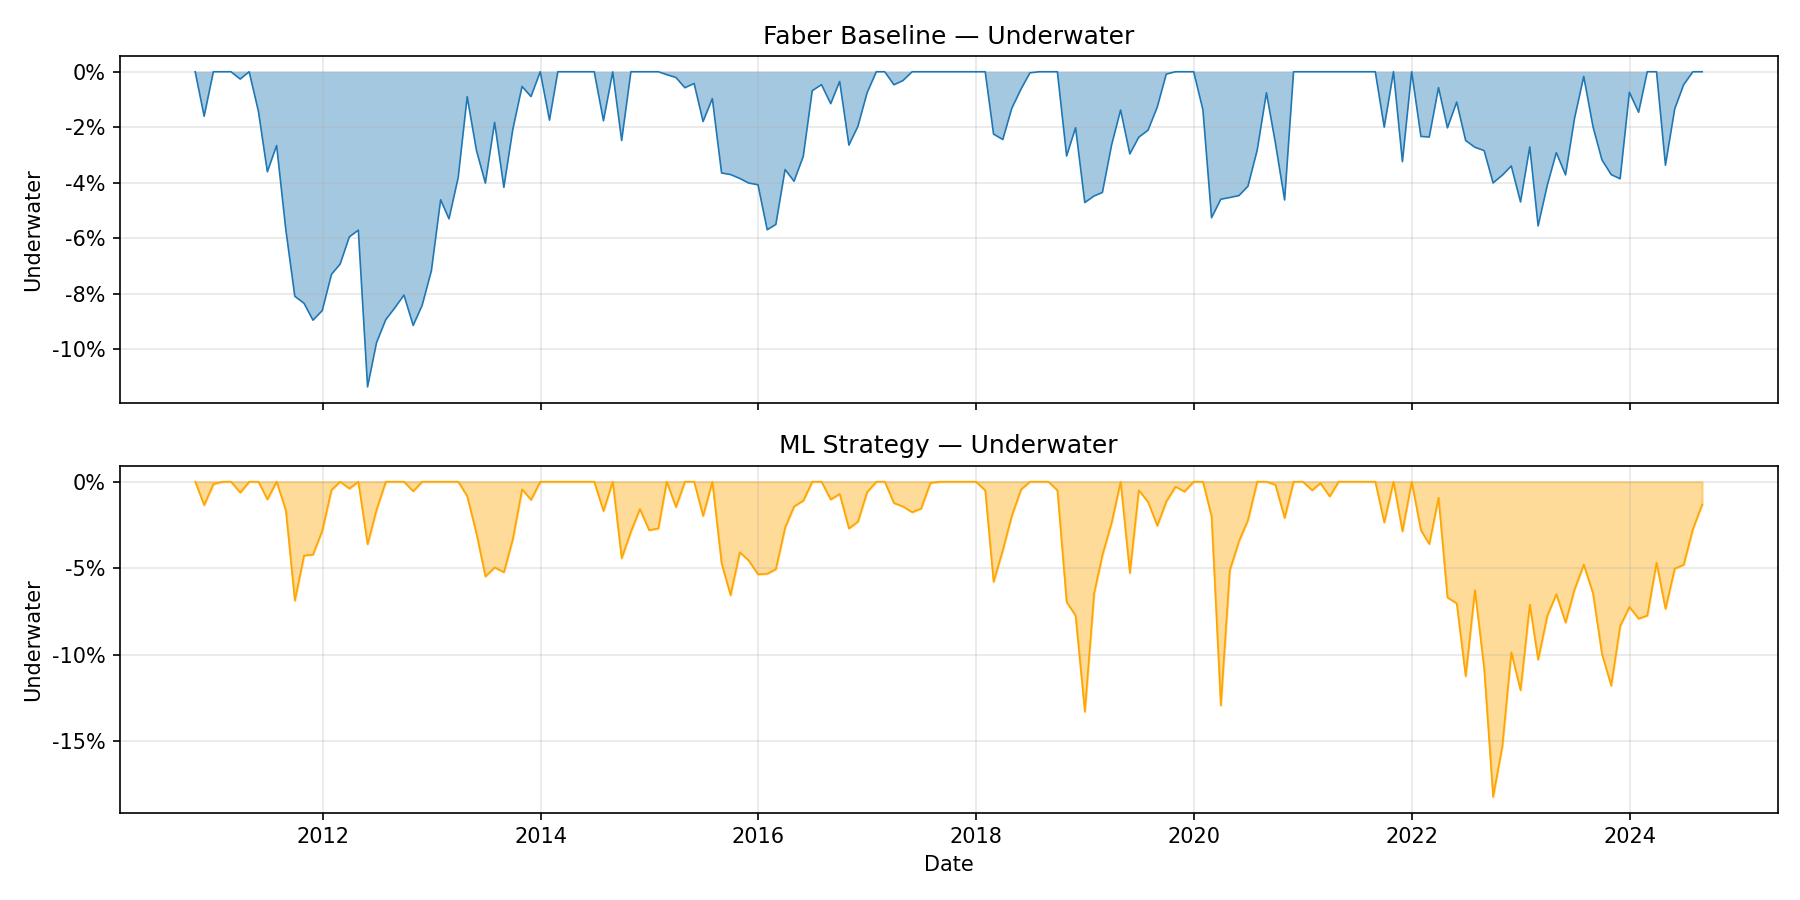

In [6]:
display(Image('../figures/cumulative_returns.png'))
display(Image('../figures/rolling_6M_sharp_ratio.png'))
display(Image('../figures/underwater.png'))

## Analysis and Conclusion
Though the ML strategy is able to compete with Faber for a while, it clearly falls behind after the COVID-19 pandemic and the 2021-2022 inflation surge, and has struggled to recover since.

Faber has good results in the early years, but around 2013, the ML strategy overtakes Faber for the first time. the ML strategy then regularly performs better than Faber, aside from a few times where they are near-similar, until around 2019, when the ML strategy sees notable dips then and in mid-2020, even if it, overall, still stays above. However, Faber once again surpasses the ML strategy around 2021, and from then on it pulls ahead while the ML strategy starts to struggle a bit, leading to the final result where Faber greatly outperforms the ML strategy. 

The Rolling 6-month Sharpe graph supports this analysis as well. The significant spike around the COVID-19 period, where Faber had a sharp spike upwards while the ML strategy had a significantly less increase, even getting close to negative, shows that Faber’s strategy was better at dealing with the pandemic compared to the ML strategy. This also explains why Faber outperforms the ML strategy since 2021, since the ML strategy was unable to recover quick enough from the pandemic. The underwater graph further supports that, as the drawdowns on the ML strategy, especially during the inflation surge in 2021 and 2022, are much worse than Faber’s. 

The reason for Faber doing well since the pandemic years is due to its "exit mechanism": when an asset falls below its SMA, the asset's 20% is moved towards cash, a much safer market. This limited its drawdowns during the pandemic. Conversely, the ML strategy did not have such an "exit mechanism" and continued to invest normally during the pandemic and inflation periods. This led to the ML strategy struggling to regain investments during a period where the economy was weak and volatile.

However, when the economy was strong, between 2013 and 2019, the ML strategy was outperforming the Faber baseline by a noticeable amount, shown by the ML strategy's spikes in the Sharpe graph as well. This is when LightGBM covered two weaknesses from Faber's strategy: its lack of macroeconomic indicators and it not addressing position sizing properly. We addressed this through the FRED/ALFRED macroeconomic data and our LightGBM x risk parity algorithm, respectively. As such, LightGBM can tilt toward the stronger-performing assets within a good market, while Faber can only do equal weight when everything is above its SMA. This can also be seen in a brief period in 2023 on the Sharpe graph, one of the only post-pandemic periods where the ML strategy performed better. 

Overall, the ML strategy developed was shown to improve on Faber's strategy during times of strong economic growth and improvement. However, as the ML strategy does not have an "exit mechanism", it falters during recessions, and can take a while to catch back up. The solution to further improve the ML strategy will be to add a similar "exit mechanism" to what Faber has, though it cannot be exactly the same or else it could have conflict with our LightGBM model.